# ORAS5 Salinity and Regridding
## 08.12.25

This notebook is split up into the following sections:

1. Salinity Plots
    - Depth dependance
    - Summer vs Winter
2. Regridding using xarray/scipy
    - Exploring regridding ORAS5 files to ERA5 grids using xarray and scipy griddata


## 1. Salinity Plots

The first task is to explore the salinity variable in greater detail. First I looked at the depth dependance around Greenland by plotting maps at various depths.

In [1]:
# Imports
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


In [2]:
# Loading files
file_paths_sal_2022 = [
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202201_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202202_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202203_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202204_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202205_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202206_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202207_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202208_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202209_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202210_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202211_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\Salinity_Velocity\vosaline_control_monthly_highres_3D_202212_OPER_v0.1.nc",
]

# Combining files into dataset
sal_ds = xr.open_mfdataset(
    file_paths_sal_2022,
    combine="nested",
    concat_dim="time_counter",
    parallel=True
)

print(sal_ds)


<xarray.Dataset> Size: 5GB
Dimensions:            (time_counter: 12, bnds: 2, deptht: 75, y: 1021, x: 1442)
Coordinates:
  * deptht             (deptht) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
    nav_lon            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
  * time_counter       (time_counter) datetime64[ns] 96B 2022-01-16T12:00:00 ...
Dimensions without coordinates: bnds, y, x
Data variables:
    time_counter_bnds  (time_counter, bnds) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
    vosaline           (time_counter, deptht, y, x) float32 5GB dask.array<chunksize=(1, 19, 341, 481), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...
    title:        Monthly mean salinity
    source:       ORAS5 - backward extension (ECMWF)
    institution:  European Centre for

Shared colour scale (psu): vmin=25.06, vmax=35.46


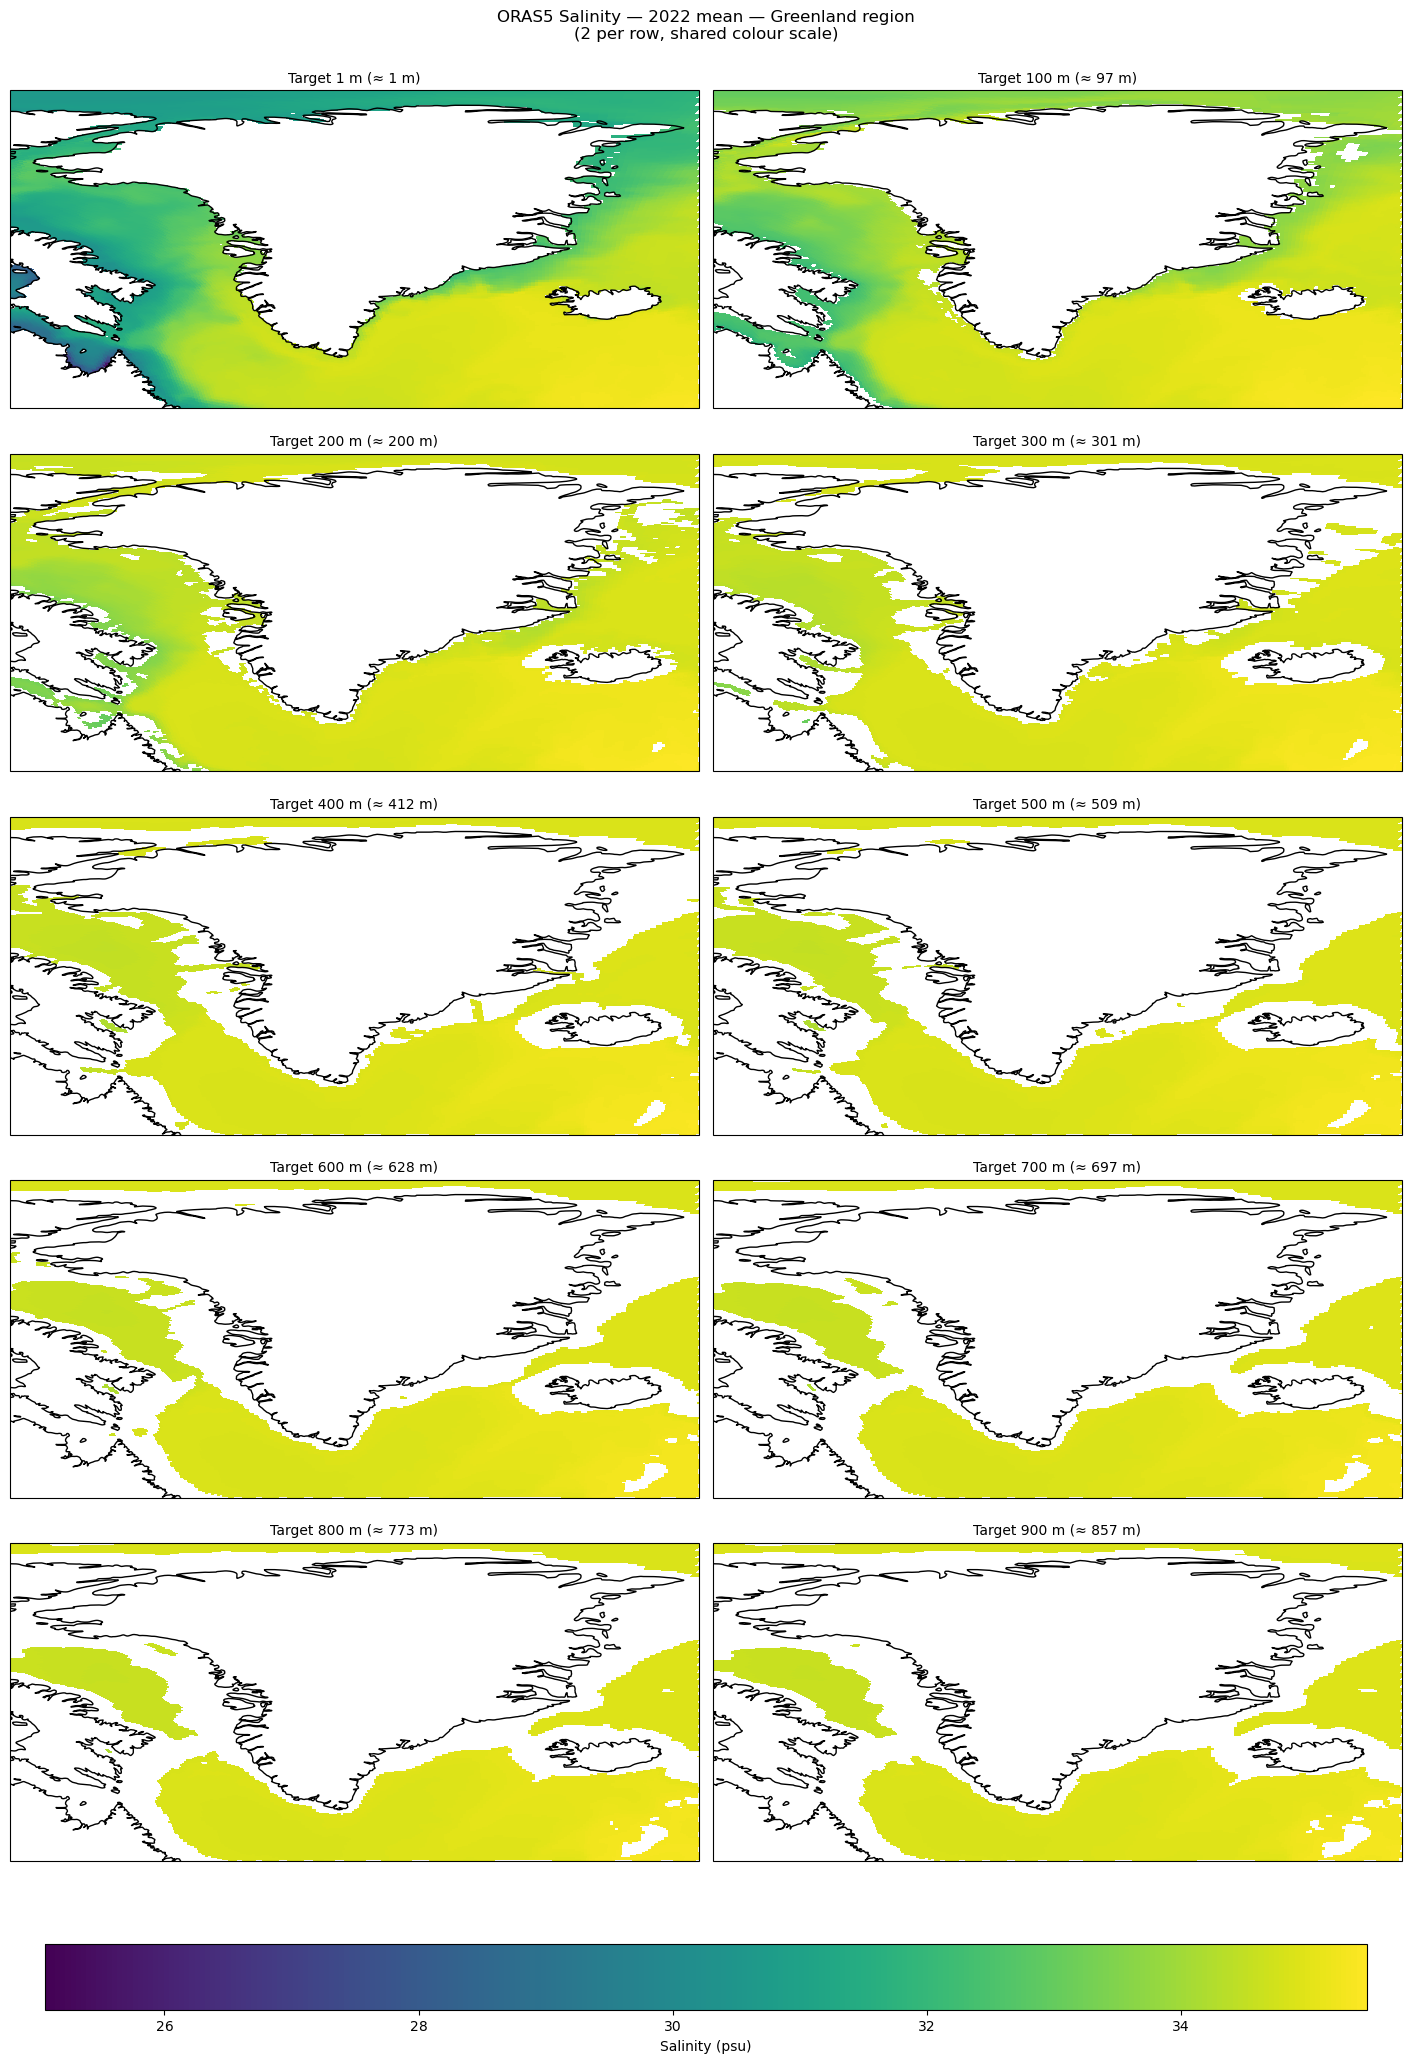

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Loading fields from dataset
sal     = sal_ds["vosaline"]
nav_lat = sal_ds["nav_lat"]
nav_lon = sal_ds["nav_lon"]
depths  = sal_ds["deptht"]

# Greenladn region
lon_min, lon_max = -75, -10
lat_min, lat_max =  55,  85

region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)

# Choosing depths
target_depths = np.array([1, 100, 200, 300, 400, 500, 600, 700, 800, 900], dtype=float)

depth_indices = [int(np.argmin(np.abs(depths.values - d))) for d in target_depths]
depth_actuals = [float(depths.values[i]) for i in depth_indices]

# 2022 AVG
sal_mean = sal.mean("time_counter")

# Extracting/masking each depth slice
fields = []
all_vals = []
for i in depth_indices:
    f = sal_mean.isel(deptht=i).where(region_mask)
    fields.append(f)
    all_vals.append(f.values)

# Shared colourscale
vmin = float(np.nanmin(all_vals))
vmax = float(np.nanmax(all_vals))
print(f"Shared colour scale (psu): vmin={vmin:.2f}, vmax={vmax:.2f}")

# Plots
nrows, ncols = 5, 2
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(14, 20),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

pm = None
for ax, field, z_target, z_actual in zip(axes.ravel(), fields, target_depths, depth_actuals):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines()

    pm = ax.pcolormesh(
        nav_lon, nav_lat, field,
        shading="auto",
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin, vmax=vmax
    )
    ax.set_title(f"Target {z_target:.0f} m (≈ {z_actual:.0f} m)", fontsize=10)

# Shared colourbar
cbar = fig.colorbar(
    pm,
    ax=axes.ravel().tolist(),
    orientation="horizontal",
    pad=0.04,
    shrink=0.95
)
cbar.set_label("Salinity (psu)")

fig.suptitle(
    "ORAS5 Salinity — 2022 mean — Greenland region\n(2 per row, shared colour scale)",
    y=1.02
)
plt.show()


Shared colour scale (psu): vmin=18.77, vmax=35.45


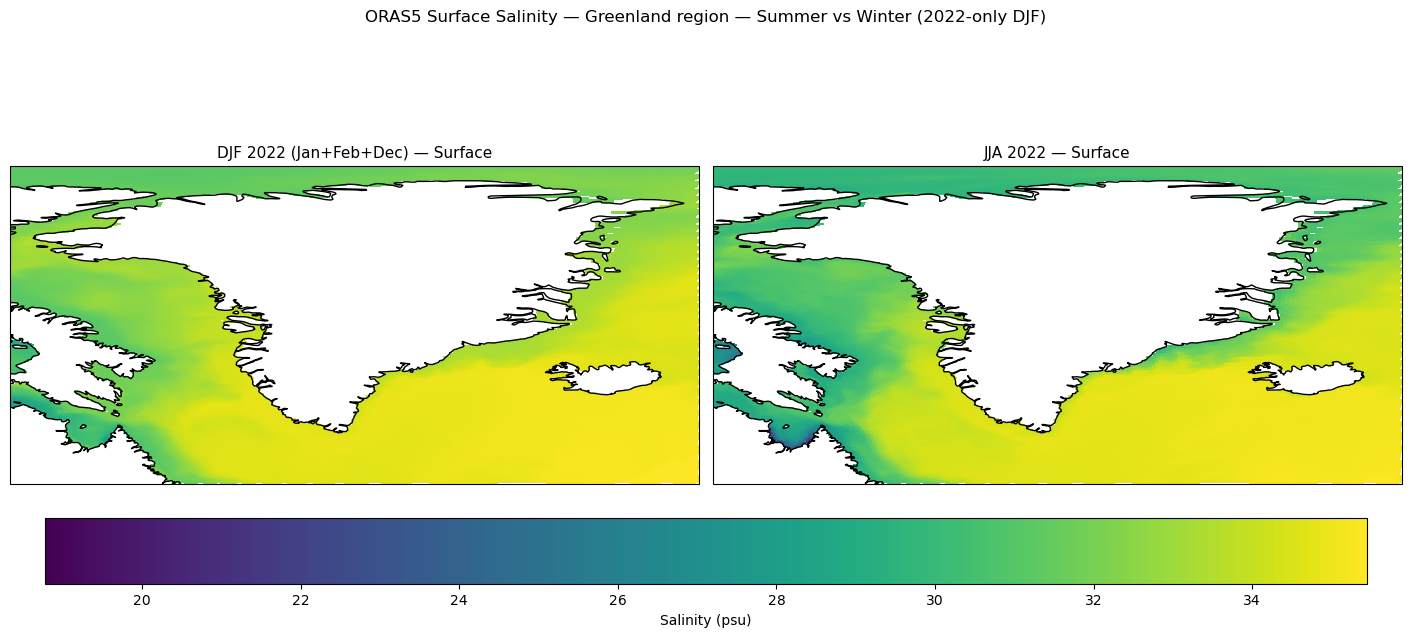

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Loading fields from dataset
sal     = sal_ds["vosaline"]
nav_lat = sal_ds["nav_lat"]
nav_lon = sal_ds["nav_lon"]

# Greenland region
lon_min, lon_max = -75, -10
lat_min, lat_max =  55,  85

region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)

# Surface level
sal_surface = sal.isel(deptht=0)

# Seasons (only 2022 values in dataset so DJF uses only 2022 months)
months = sal_ds["time_counter"].dt.month
jja_mask = (months >= 6) & (months <= 8)
djf_mask = (months == 12) | (months <= 2)

sal_jja = sal_surface.sel(time_counter=jja_mask).mean("time_counter").where(region_mask)
sal_djf = sal_surface.sel(time_counter=djf_mask).mean("time_counter").where(region_mask)

# Shared colourscale
vmin = float(np.nanmin([sal_jja.values, sal_djf.values]))
vmax = float(np.nanmax([sal_jja.values, sal_djf.values]))
print(f"Shared colour scale (psu): vmin={vmin:.2f}, vmax={vmax:.2f}")

# Plots
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

pm = None
for ax, field, title in zip(
    axes,
    [sal_djf, sal_jja],
    ["DJF 2022 (Jan+Feb+Dec) — Surface", "JJA 2022 — Surface"]
):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.coastlines()

    pm = ax.pcolormesh(
        nav_lon, nav_lat, field,
        shading="auto",
        transform=ccrs.PlateCarree(),
        cmap="viridis",
        vmin=vmin, vmax=vmax
    )
    ax.set_title(title, fontsize=11)

# Shared colourbar
cbar = fig.colorbar(pm, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.06, shrink=0.95)
cbar.set_label("Salinity (psu)")

fig.suptitle("ORAS5 Surface Salinity — Greenland region — Summer vs Winter (2022-only DJF)", y=1.03)
plt.show()


Shared colour scale (psu): vmin=18.77, vmax=35.47


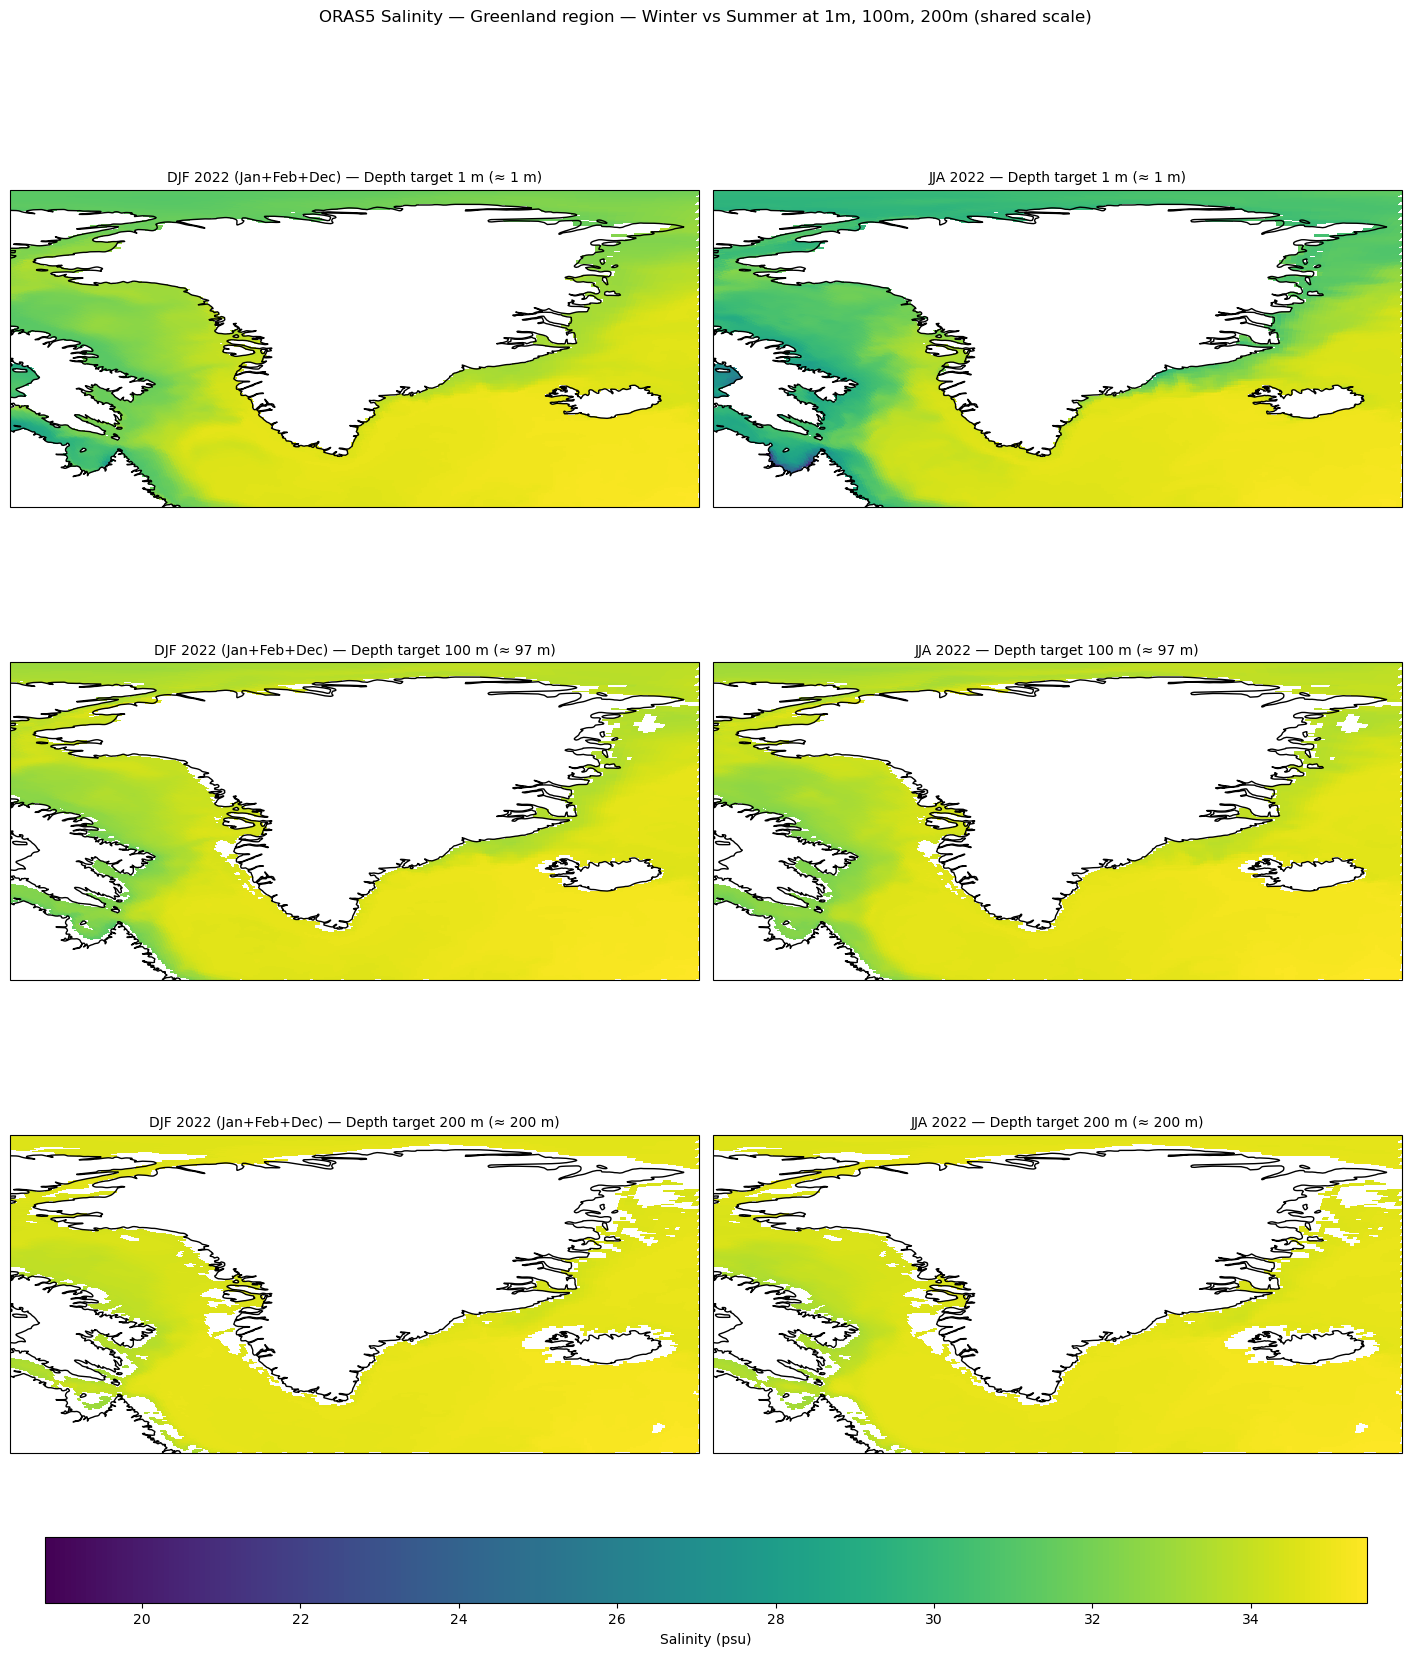

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# Loading fields from dataset
sal     = sal_ds["vosaline"]
nav_lat = sal_ds["nav_lat"]
nav_lon = sal_ds["nav_lon"]
depths  = sal_ds["deptht"]

# Greenland region
lon_min, lon_max = -75, -10
lat_min, lat_max =  55,  85

region_mask = (
    (nav_lon >= lon_min) & (nav_lon <= lon_max) &
    (nav_lat >= lat_min) & (nav_lat <= lat_max)
)

# Seasons
months = sal_ds["time_counter"].dt.month
jja_mask = (months >= 6) & (months <= 8)
djf_mask = (months == 12) | (months <= 2)

# Depths
target_depths = np.array([1, 100, 200], dtype=float)
depth_indices = [int(np.argmin(np.abs(depths.values - d))) for d in target_depths]
depth_actuals = [float(depths.values[i]) for i in depth_indices]

# Calc seasonal avgs at each depth
djf_fields, jja_fields = [], []
for i in depth_indices:
    sal_z = sal.isel(deptht=i)
    djf_fields.append(sal_z.sel(time_counter=djf_mask).mean("time_counter").where(region_mask))
    jja_fields.append(sal_z.sel(time_counter=jja_mask).mean("time_counter").where(region_mask))

# SHared colourscale
all_vals = [f.values for f in (djf_fields + jja_fields)]
vmin = float(np.nanmin(all_vals))
vmax = float(np.nanmax(all_vals))
print(f"Shared colour scale (psu): vmin={vmin:.2f}, vmax={vmax:.2f}")

# Plots
fig, axes = plt.subplots(
    3, 2,
    figsize=(14, 16),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

pm = None
for r in range(3):
    for c in range(2):
        ax = axes[r, c]
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
        ax.coastlines()

        field = djf_fields[r] if c == 0 else jja_fields[r]
        season = "DJF 2022 (Jan+Feb+Dec)" if c == 0 else "JJA 2022"

        pm = ax.pcolormesh(
            nav_lon, nav_lat, field,
            shading="auto",
            transform=ccrs.PlateCarree(),
            cmap="viridis",
            vmin=vmin, vmax=vmax
        )

        ax.set_title(f"{season} — Depth target {target_depths[r]:.0f} m (≈ {depth_actuals[r]:.0f} m)", fontsize=10)

# Shared colourbar
cbar = fig.colorbar(pm, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.05, shrink=0.95)
cbar.set_label("Salinity (psu)")

fig.suptitle("ORAS5 Salinity — Greenland region — Winter vs Summer at 1m, 100m, 200m (shared scale)", y=1.02)
plt.show()


## 2. Regridding

Unfortunately I couldn't get xesmf to work on my computer. Instead I looked to other regridding methods. One such method involved the use of the scipy griddata module, which is what I use below.

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.interpolate import griddata


In [5]:
file_paths = [
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202201_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202202_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202203_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202204_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202205_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202206_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202207_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202208_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202209_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202210_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202211_OPER_v0.1.nc",
    r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\ORAS5\SST_2022\sosstsst_control_monthly_highres_2D_202212_OPER_v0.1.nc",
]

oras5_ds = xr.open_mfdataset(
    file_paths,
    combine="nested",
    concat_dim="time_counter"
)

print(oras5_ds)


<xarray.Dataset> Size: 82MB
Dimensions:            (time_counter: 12, y: 1021, x: 1442, bnds: 2)
Coordinates:
    nav_lat            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
    nav_lon            (y, x) float32 6MB dask.array<chunksize=(1021, 1442), meta=np.ndarray>
  * time_counter       (time_counter) datetime64[ns] 96B 2022-01-16T12:00:00 ...
Dimensions without coordinates: y, x, bnds
Data variables:
    sosstsst           (time_counter, y, x) float32 71MB dask.array<chunksize=(1, 1021, 1442), meta=np.ndarray>
    time_counter_bnds  (time_counter, bnds) datetime64[ns] 192B dask.array<chunksize=(1, 2), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    NCO:          netCDF Operators version 4.9.6 (Homepage = http://nco.sf.ne...
    title:        Monthly mean 2D Sea Surface fields
    source:       ORAS5 - backward extension (ECMWF)
    institution:  European Centre for Medium-Range Weather Forecasts (ECMWF) ...
    reference:    https://www.ecmwf

In [6]:
sst = oras5_ds["sosstsst"]
nav_lat = oras5_ds["nav_lat"]
nav_lon = oras5_ds["nav_lon"]

sst_annual = sst.mean("time_counter")

In [10]:
file_path_b = r"C:\Users\itsna\OneDrive\Desktop\MSc_Work\DataSets\data_stream-moda_stepType-avgua.nc"

colour_map = "Spectral_r"

era5_ds = xr.open_dataset(file_path_b)

In [12]:
# ERA5 lat/lon
lat_t = era5_ds["latitude"].values
lon_t = era5_ds["longitude"].values

lon2, lat2 = np.meshgrid(lon_t, lat_t)


In [13]:
# Flatten ORAS5 grid
src_lon = nav_lon.values.ravel()
src_lat = nav_lat.values.ravel()
src_val = sst_annual.values.ravel()

# Remove nan vals from ORAS5
mask = np.isfinite(src_lon) & np.isfinite(src_lat) & np.isfinite(src_val)
points = np.column_stack([src_lon[mask], src_lat[mask]])
values = src_val[mask]

# Interpolate (chooses 3 nearest points to avg)
sst_era5 = griddata(
    points,
    values,
    (lon2, lat2),
    method="linear")

# Fill coast gaps with (single) nearest neighbour
sst_era5_nn = griddata(points, values, (lon2, lat2), method="nearest")
sst_era5 = np.where(np.isfinite(sst_era5), sst_era5, sst_era5_nn)


In [37]:
# Turning oras5 sst into array and assigning era5 lat/lons
sst_era5_da = xr.DataArray(
    sst_era5,
    dims=("latitude", "longitude"),
    coords={
        "latitude": lat_t,
        "longitude": lon_t
    },
    name="sst_oras5_regridded")

sst_era5_da.attrs["description"] = "ORAS5 SST (2022 annual mean) regridded to ERA5 grid using scipy.griddata"

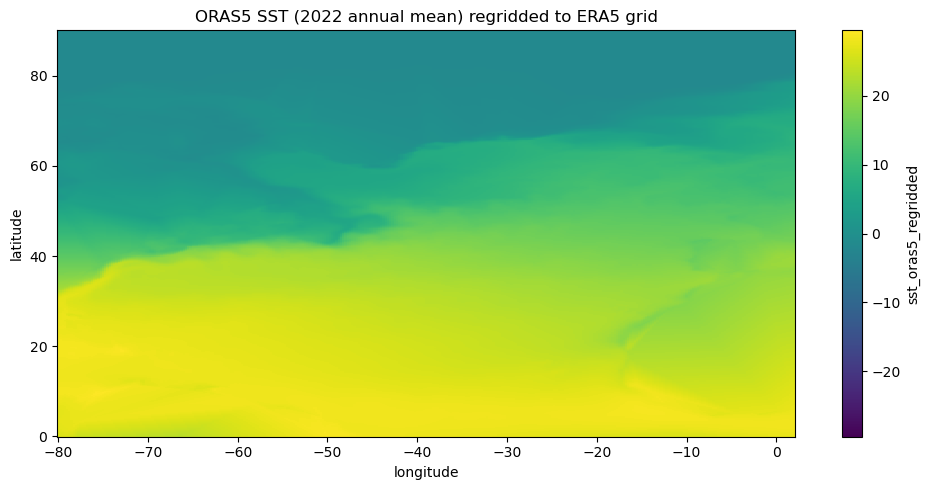

In [15]:
plt.figure(figsize=(10, 5))
sst_era5_da.plot(cmap="viridis")
plt.title("ORAS5 SST (2022 annual mean) regridded to ERA5 grid")
plt.tight_layout()
plt.show()


Above is a plot of the raw regridded data. Notably there are no coastlines or nan values over land areas. This is because the regridding fills every grid cell with some estimate value based on its nearest neighbours, even the nan values. To rectify this I created a mask of the ERA5 land (nan) values and applied this to our new regridded data.

In [33]:
era5_sst = era5_ds["sst"]

# just taking first time step
era5_sst_2d = era5_sst.isel(valid_time=0)

# Creating oceanmask (false for nan values)
ocean_mask = np.isfinite(era5_sst_2d.values)

In [36]:
# applying mask to regridded oras5 data (nan values over land)
sst_oras5_masked = sst_era5_da.where(ocean_mask)

sst_oras5_masked.name = "sst_oras5_regridded_masked"
sst_oras5_masked.attrs["mask_note"] = "Masked using ERA5 SST NaN pattern (land = NaN)"

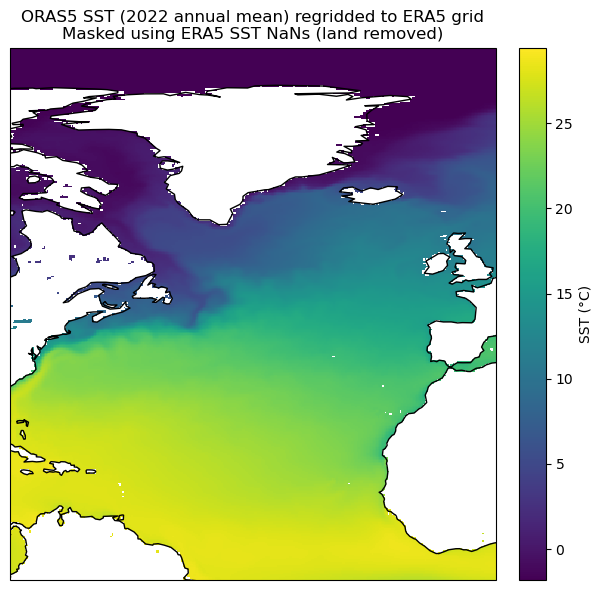

In [23]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

lon_t = sst_oras5_masked["longitude"].values
lat_t = sst_oras5_masked["latitude"].values

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    lon_t, lat_t, sst_oras5_masked.values,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis"
)

plt.colorbar(pm, orientation="vertical", pad=0.02, label="SST (°C)")
plt.title("ORAS5 SST (2022 annual mean) regridded to ERA5 grid\nMasked using ERA5 SST NaNs (land removed)")
plt.tight_layout()
plt.show()


We can now see that (aside for some slight errors) the land areas are mostly filled with nan values. To compare this new regridded dataset to ERA5 data, I then plotted them side-by-side.

In [35]:
# era5 in celcius
era5_sst = era5_ds["sst"] - 273.15

# Annual 2022 AVG
era5_sst_annual = era5_sst.mean("valid_time")

In [38]:
# Making sure only ocean values compared
vals = [sst_oras5_masked.values, era5_sst_annual.values]

vmin = float(np.nanmin(vals))
vmax = float(np.nanmax(vals))
print(f"Shared colour scale: vmin={vmin:.2f}, vmax={vmax:.2f}")

Shared colour scale: vmin=-1.81, vmax=30.78


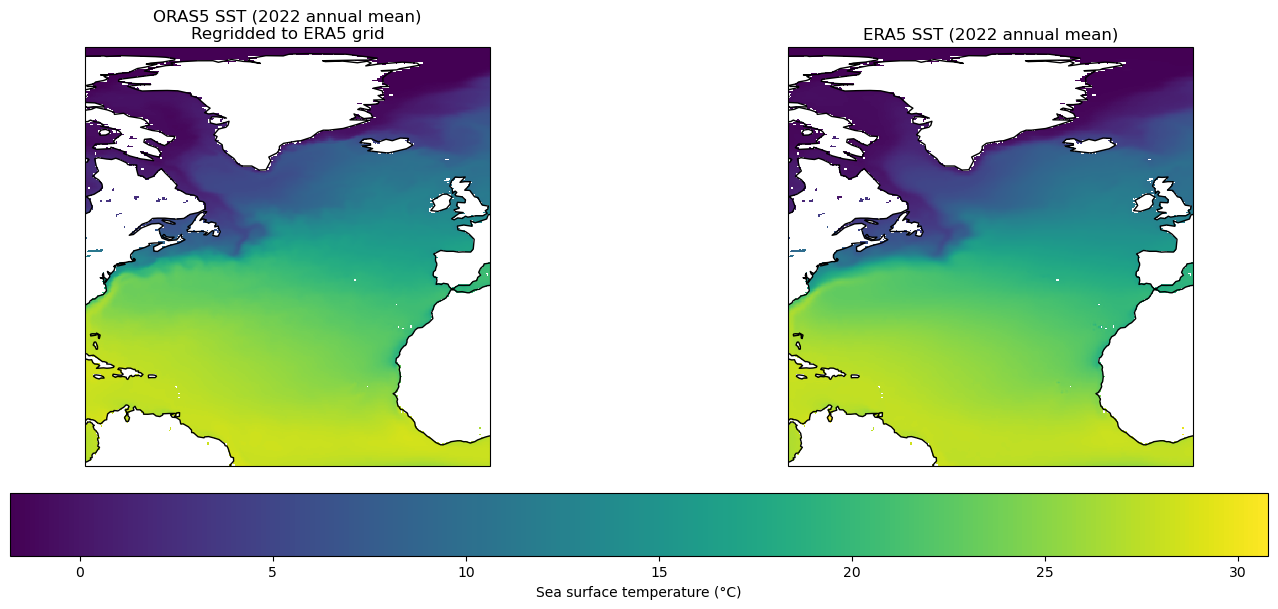

In [29]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

lon = sst_oras5_masked["longitude"].values
lat = sst_oras5_masked["latitude"].values

lon_min, lon_max = -80, 2
lat_min, lat_max = 0, 85

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True
)

# regridded oras5
ax = axes[0]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

pm = ax.pcolormesh(
    lon, lat, sst_oras5_masked.values,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=vmin, vmax=vmax
)
ax.set_title("ORAS5 SST (2022 annual mean)\nRegridded to ERA5 grid")

# era5
ax = axes[1]
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.coastlines()

ax.pcolormesh(
    lon, lat, era5_sst_annual.values,
    shading="auto",
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=vmin, vmax=vmax
)
ax.set_title("ERA5 SST (2022 annual mean)")

# Shared colourbar
cbar = fig.colorbar(pm, ax=axes.ravel().tolist(), orientation="horizontal", pad=0.05)
cbar.set_label("Sea surface temperature (°C)")

plt.show()
